###  Architecture 
Here tabular encoder widtha and depth increased to see the effect of tabular encoder 



In [1]:
import os
import sys
sys.path.insert(0, os.path.abspath("../.."))

In [2]:
# Cell 1: imports & setup
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gc

gc.enable()

import torch
from torch.utils.data import DataLoader
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error

from src.config import EXP_CONFIGS
from src.utils import set_seed, save_config
from src.data import build_transforms, ImageTabDataset
from src.models import FeatureConcatFusionNet



main_folder = "../.."
data_csv = os.path.join(main_folder, "data", "train.csv")
img_folder = os.path.join(main_folder, "data", "train")
out_dir = os.path.join(main_folder, "outputs", "extra","exp5_SwinT_StrongAug_LinearHead_tabEncoder_big")

df = pd.read_csv(data_csv)
cfg = EXP_CONFIGS["exp5"]   # define in config
cfg["head_type"] = "linear"
cfg["name"] = "exp5_SwinT_StrongAug_LinearHead_tabEncoder_big"
TARGET = "Pawpularity"
tab_cols = [c for c in df.columns if c not in ["Id", TARGET]]

os.makedirs(out_dir, exist_ok=True)
save_config(cfg, out_dir)
set_seed(cfg["seed"])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


/home/ghias/miniconda3/envs/rapids-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error
from src.train import run_single_fold

kf = KFold(n_splits=cfg["n_splits"], shuffle=True, random_state=cfg["seed"])
oof_pred = np.zeros(len(df))
oof_true = df[TARGET].values
fold_index = np.full(len(df), -1, dtype=int)
fold_rmse = []

start_all = time.time()
for fold, (tr_idx, val_idx) in enumerate(kf.split(df), start=1):
    print(f"\n=== {cfg['name']}: Fold {fold} ===")
    train_df = df.iloc[tr_idx].reset_index(drop=True)
    val_df   = df.iloc[val_idx].reset_index(drop=True)

    best_rmse, val_preds, val_targets, val_ids = run_single_fold(
    fold=fold,
    train_df=train_df,
    val_df=val_df,
    img_folder=img_folder,
    cfg=cfg,
    out_dir=out_dir,
    device=device,
    mode="fusion",      #  fusion
    tab_cols=tab_cols,
    workers=16,
    pin_memory=True,
    persistent_workers=True,
    tab_encoder_capacity="big", # "small" is 2-layer MLP, "big" is deeper and wider 5-layer MLP
    )

    oof_pred[val_idx] = val_preds
    fold_index[val_idx] = fold
    fold_rmse.append(best_rmse)
    print(f"Fold {fold} best RMSE: {best_rmse:.4f}")

all_sec = time.time() - start_all
print(f"\nTotal training time: {int(all_sec//60)}m {int(all_sec%60)}s")
# final metrics + OOF with fold column
oof_rmse = root_mean_squared_error(oof_true, oof_pred)
fold_rmse = np.array(fold_rmse)
print(f"\nOOF RMSE: {oof_rmse:.4f}")
print(f"Fold RMSEs: {fold_rmse.tolist()}  Mean={fold_rmse.mean():.4f}  Std={fold_rmse.std():.4f}")

oof_df = pd.DataFrame({
    "Id": df["Id"],
    "fold": fold_index,      #  fold for each sample
    "ytrue": oof_true,
    "oof_pred": oof_pred,
})
oof_df["abs_err"] = (oof_df["ytrue"] - oof_df["oof_pred"]).abs()
oof_df.to_csv(os.path.join(out_dir, "oof_detail.csv"), index=False)
oof_df.sort_values("abs_err", ascending=False).head(50).to_csv(
    os.path.join(out_dir, "top50_errors.csv"), index=False
)

np.save(os.path.join(out_dir, "oof_pred.npy"), oof_pred)
np.save(os.path.join(out_dir, "fold_rmse.npy"), fold_rmse)
with open(os.path.join(out_dir, "metrics.txt"), "w") as f:
    f.write(f"OOF_RMSE: {oof_rmse:.4f}\n")
    f.write(f"Fold_RMSE: {fold_rmse.tolist()}\nMean: {fold_rmse.mean():.4f}\nStd: {fold_rmse.std():.4f}\n")



=== exp5_SwinT_StrongAug_LinearHead_tabEncoder_big: Fold 1 ===
Epoch 1/10 | Fold 1 | Train[BCE]: Loss=0.6500 | ValRMSE: 18.0524
Epoch 2/10 | Fold 1 | Train[BCE]: Loss=0.6399 | ValRMSE: 18.1178
Epoch 3/10 | Fold 1 | Train[BCE]: Loss=0.6323 | ValRMSE: 17.9169
Epoch 4/10 | Fold 1 | Train[BCE]: Loss=0.6230 | ValRMSE: 17.9354
Epoch 5/10 | Fold 1 | Train[BCE]: Loss=0.6141 | ValRMSE: 18.6761
Epoch 6/10 | Fold 1 | Train[BCE]: Loss=0.6055 | ValRMSE: 18.4761
Epoch 7/10 | Fold 1 | Train[BCE]: Loss=0.5991 | ValRMSE: 18.7113
Epoch 8/10 | Fold 1 | Train[BCE]: Loss=0.5943 | ValRMSE: 18.7835
Early stopping at epoch 8
Fold 1 best RMSE: 17.9169

=== exp5_SwinT_StrongAug_LinearHead_tabEncoder_big: Fold 2 ===
Epoch 1/10 | Fold 2 | Train[BCE]: Loss=0.6478 | ValRMSE: 18.3510
Epoch 2/10 | Fold 2 | Train[BCE]: Loss=0.6384 | ValRMSE: 17.8390
Epoch 3/10 | Fold 2 | Train[BCE]: Loss=0.6303 | ValRMSE: 18.4182
Epoch 4/10 | Fold 2 | Train[BCE]: Loss=0.6211 | ValRMSE: 18.1960
Epoch 5/10 | Fold 2 | Train[BCE]: Loss=0

In [12]:
import pandas
df = pd.read_csv(out_dir+"/oof_detail.csv")

for fold in range(1, 6):
    sub = df[df.fold == fold]
    rmse = ((sub.ytrue - sub.oof_pred)**2).mean() ** 0.5
    print(f"Fold {fold} OOF RMSE: {rmse:.4f} (n={len(sub)})")


Fold 1 OOF RMSE: 17.9169 (n=1983)
Fold 2 OOF RMSE: 17.8390 (n=1983)
Fold 3 OOF RMSE: 17.1853 (n=1982)
Fold 4 OOF RMSE: 17.7217 (n=1982)
Fold 5 OOF RMSE: 18.0536 (n=1982)


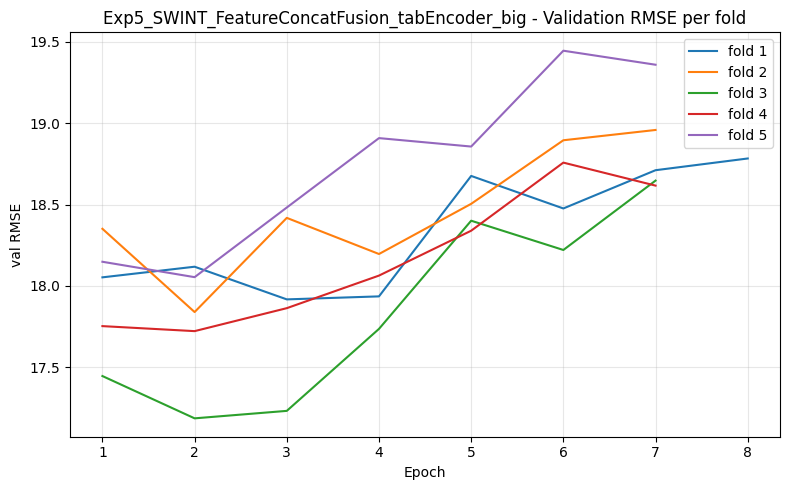

In [13]:
from src.plot import plot_all_folds_history
plot_all_folds_history(out_dir, folds=[1,2,3,4,5], title_prefix="Exp5_SWINT_FeatureConcatFusion_tabEncoder_big")

In [14]:
#  Inspect worst error rows

errors_path = os.path.join(out_dir, "top50_errors.csv")
err_df = pd.read_csv(errors_path)
err_df.head()

,Id,fold,ytrue,oof_pred,abs_err
0,4c1e05895368c997fdd709bbd1ac3dae,2,2,81.737984,79.737984
1,9fdfa0708e98d8320e0b526315bb264a,5,7,83.274239,76.274239
2,9a76b2c5d66bc2140b53ca89a296442d,5,8,83.392387,75.392387
3,941e532a21f7edb21766e88a15e588cb,4,100,24.773262,75.226738
4,e638853bdec13e6cc76b69f169b34740,4,96,22.082388,73.917612


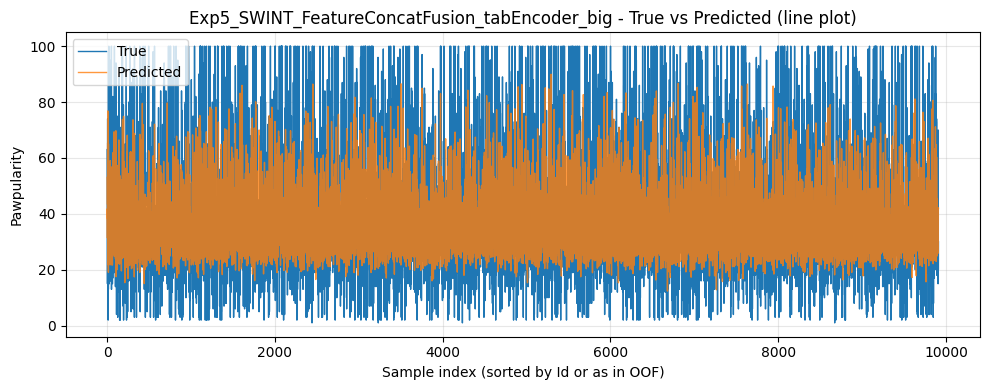

In [15]:
import os
import pandas as pd
from src.plot import (
   plot_oof_true_pred_lines,
    show_images_grid,
)

# Load OOF detail and top-errors
oof_df = pd.read_csv(os.path.join(out_dir, "oof_detail.csv"))
err_df = pd.read_csv(os.path.join(out_dir, "top50_errors.csv"))

# Plots
plot_oof_true_pred_lines(oof_df, title_prefix="Exp5_SWINT_FeatureConcatFusion_tabEncoder_big")





Exp5_Swin_EarlyFusionMLPHead OOF RMSE: 17.60001884040648
Exp5_SWINT_FeatureConcatFusion_tabEncoder_big OOF RMSE: 17.745846964610955
ΔRMSE (Exp5_SWINT_FeatureConcatFusion_tabEncoder_big - Exp5_Swin_EarlyFusionMLPHead): 0.1458281242044741


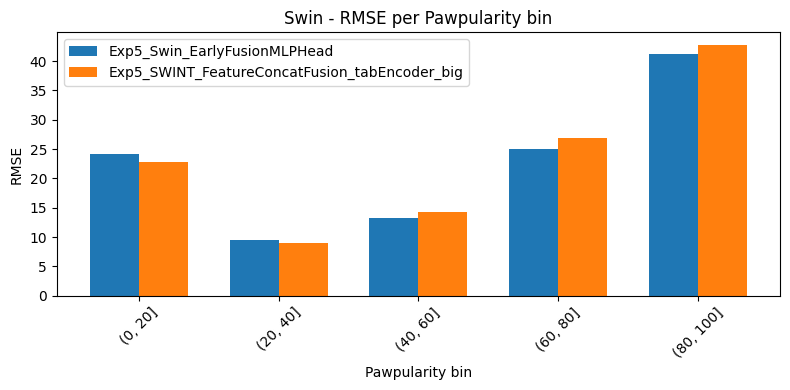

In [16]:
from src.plot import compare_oof_by_bins
bins = [0, 20, 40, 60, 80, 100]

df_bins, rmse3_all, rmse5_all, gap = compare_oof_by_bins(
    oof_path_a="../../outputs/exp5/oof_detail.csv",
    oof_path_b=out_dir+"/oof_detail.csv",
    bins=bins,
    label_a="Exp5_Swin_EarlyFusionMLPHead",
    label_b="Exp5_SWINT_FeatureConcatFusion_tabEncoder_big",
    title_prefix="Swin",
)

In [17]:
df_bins.head()

,bin,count,Exp5_Swin_EarlyFusionMLPHead_rmse,Exp5_SWINT_FeatureConcatFusion_tabEncoder_big_rmse,rmse_diff,winner
0,"(0, 20]",1417,24.173492,22.843109,-1.330383,Exp5_SWINT_FeatureConcatFusion_tabEncoder_big_...
1,"(20, 40]",5119,9.572831,8.912882,-0.659949,Exp5_SWINT_FeatureConcatFusion_tabEncoder_big_...
2,"(40, 60]",2088,13.258303,14.248545,0.990241,Exp5_Swin_EarlyFusionMLPHead_better
3,"(60, 80]",727,24.983769,26.867843,1.884074,Exp5_Swin_EarlyFusionMLPHead_better
4,"(80, 100]",561,41.202795,42.779351,1.576556,Exp5_Swin_EarlyFusionMLPHead_better


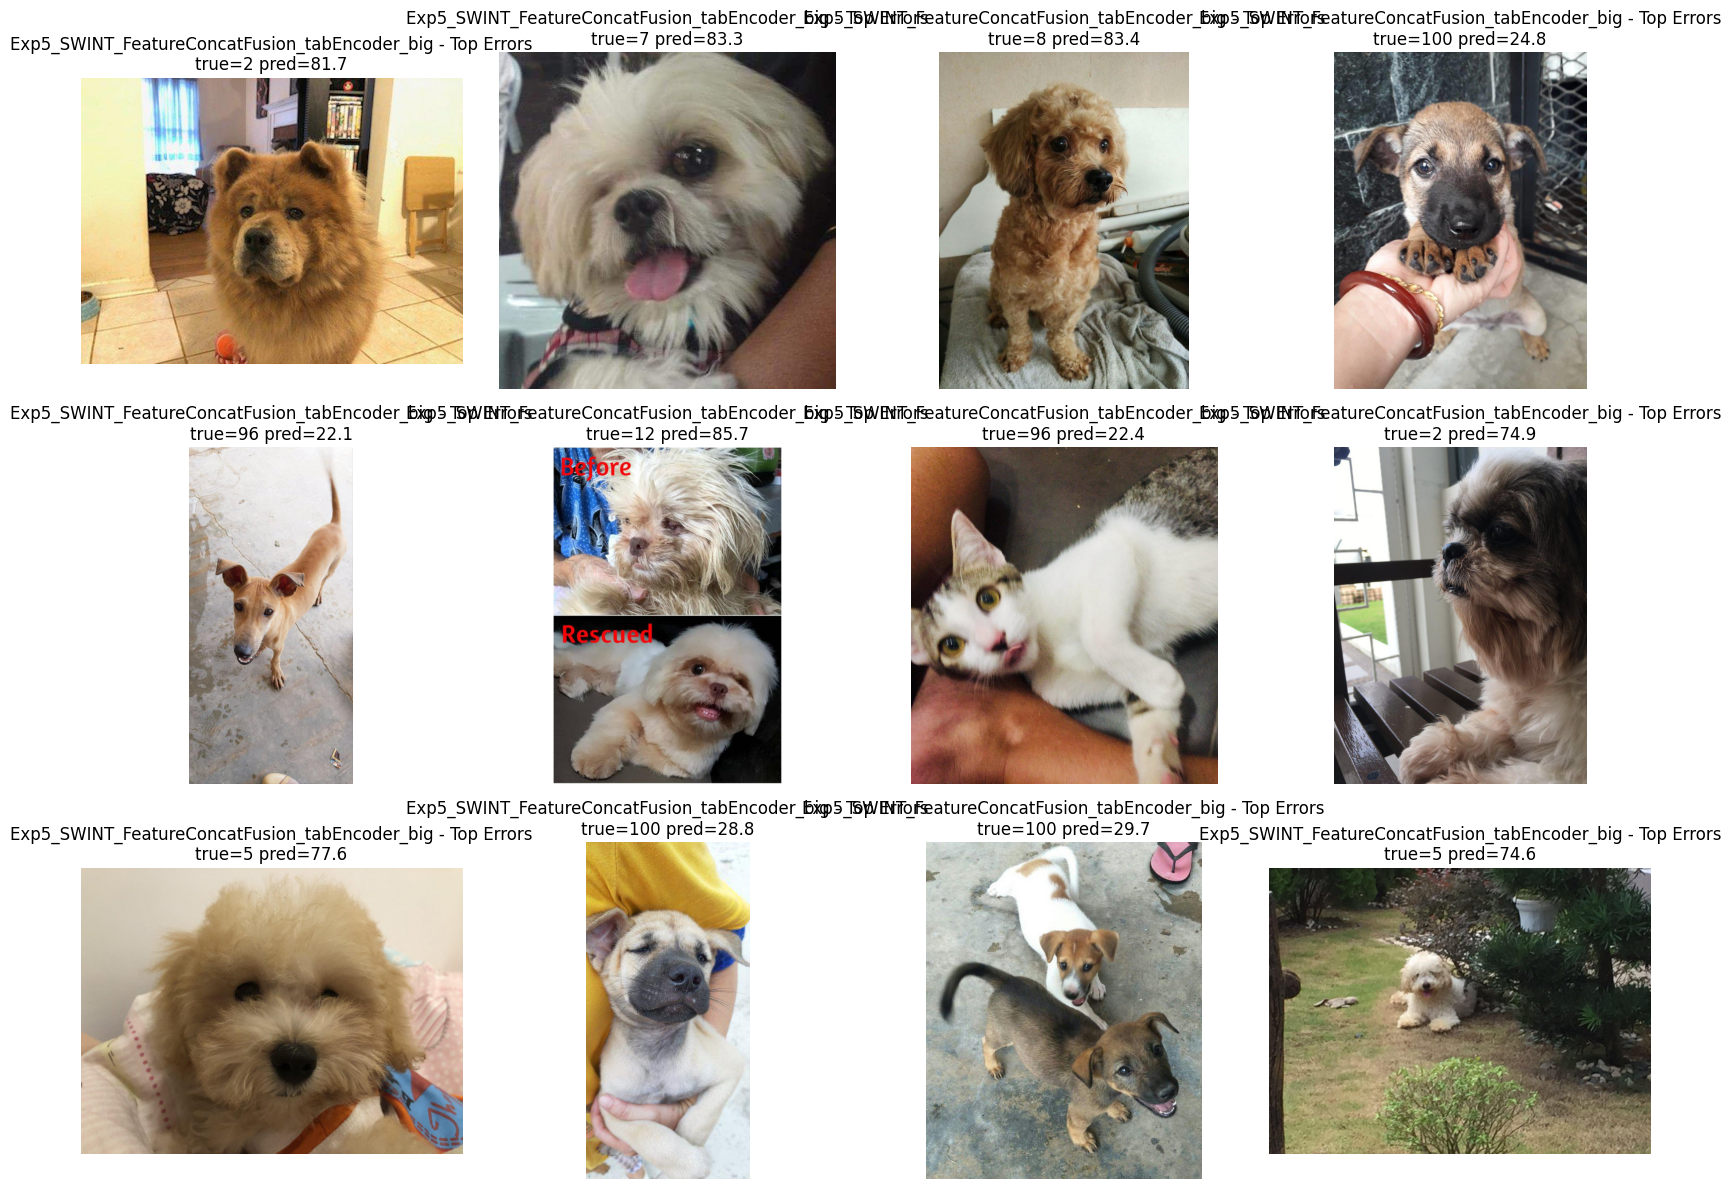

In [18]:
# Images of worst errors
img_folder = os.path.join(main_folder, "data", "train")
show_images_grid(err_df, img_folder, n=12, title_prefix="Exp5_SWINT_FeatureConcatFusion_tabEncoder_big - Top Errors")

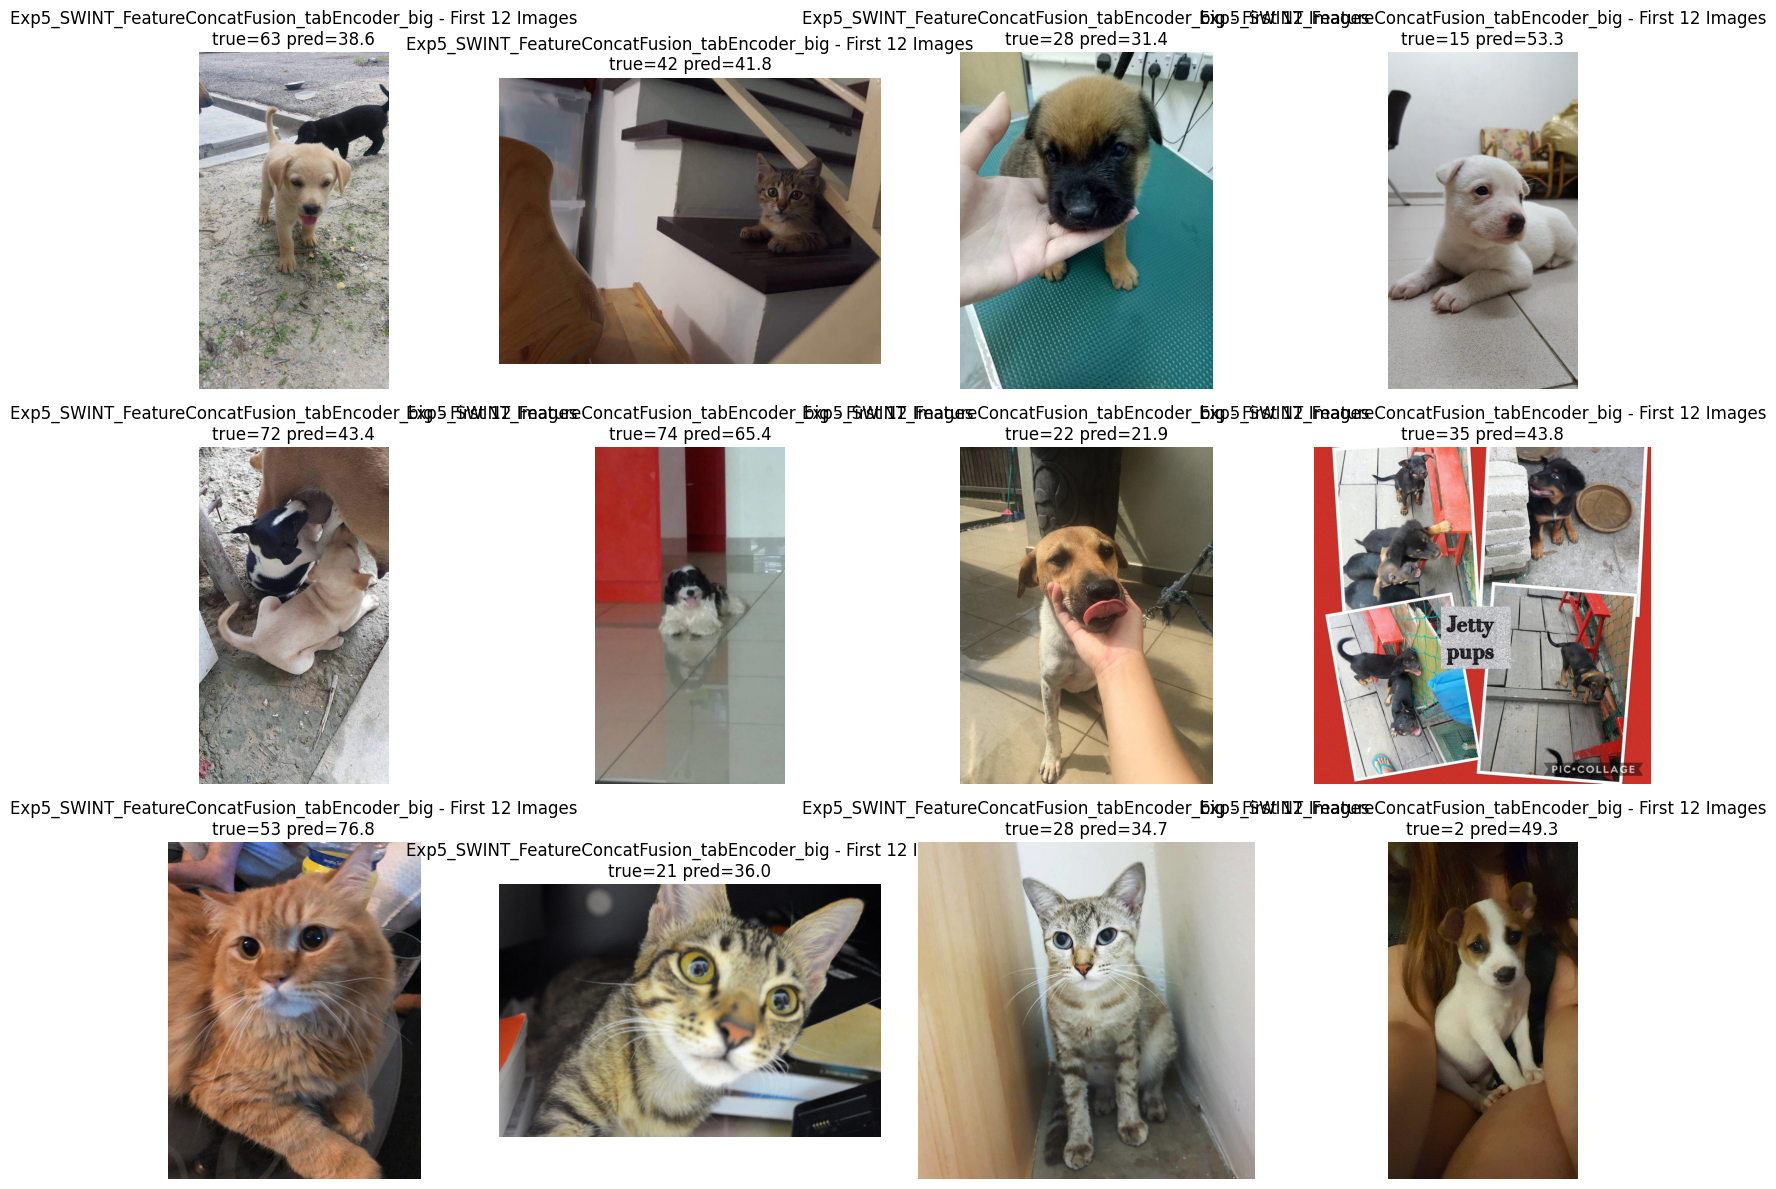

In [19]:

show_images_grid(oof_df, img_folder, n=12, title_prefix="Exp5_SWINT_FeatureConcatFusion_tabEncoder_big - First 12 Images")